In [1]:
import numpy as np
import pandas as pd

from experiments import utils
from package_name.training.utils import sampling
from package_name.training.vae import VAE, VAEConfig
from package_name.tuning.cross_validator import CrossValidator
from package_name.data_processing import data_processor
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.metrics import compute_BSS_clusters_target, compute_BSS_quantile_prediction, compute_BSS_quantile_exceedance

%load_ext autoreload
%autoreload 2

## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
filepath = "results/cmmvae/"
cluster_number = 7
original_dim = 825
pr_cluster_number = 5
batch_size = 128
epochs = 150


## Data pre-processing

In [3]:
# Get training data
z500 = utils.preprocess_dataset(filename ='data/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'new atlantic',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv('data/CHIRPS_pr_cluster_labels_5.csv')
pr_labels.columns = ['index', 'labels']
pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

## Define model

In [4]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=15,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

vae = VAE(cfg=config,  path_to_save_weights=filepath)
vae.compile()


In [5]:
history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 379.7309 - val_loss: 277.8625
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 211.9517 - val_loss: 171.2478
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 152.8821 - val_loss: 133.4823
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 130.0218 - val_loss: 125.3646
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 120.4500 - val_loss: 111.6077
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 106.5274 - val_loss: 101.5831
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 97.7478 - val_loss: 92.5361
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 90.8950 - val_loss: 88.5780
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.8140 - val_loss: 86.2609
Epoch 10/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 84.8708 - val_loss: 83.3808
Epoch 11/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.2110 - val_loss: 82.7367
Epoch 12/150
35/35 ━━━━━━━━━━

## Plot training and validation losses.

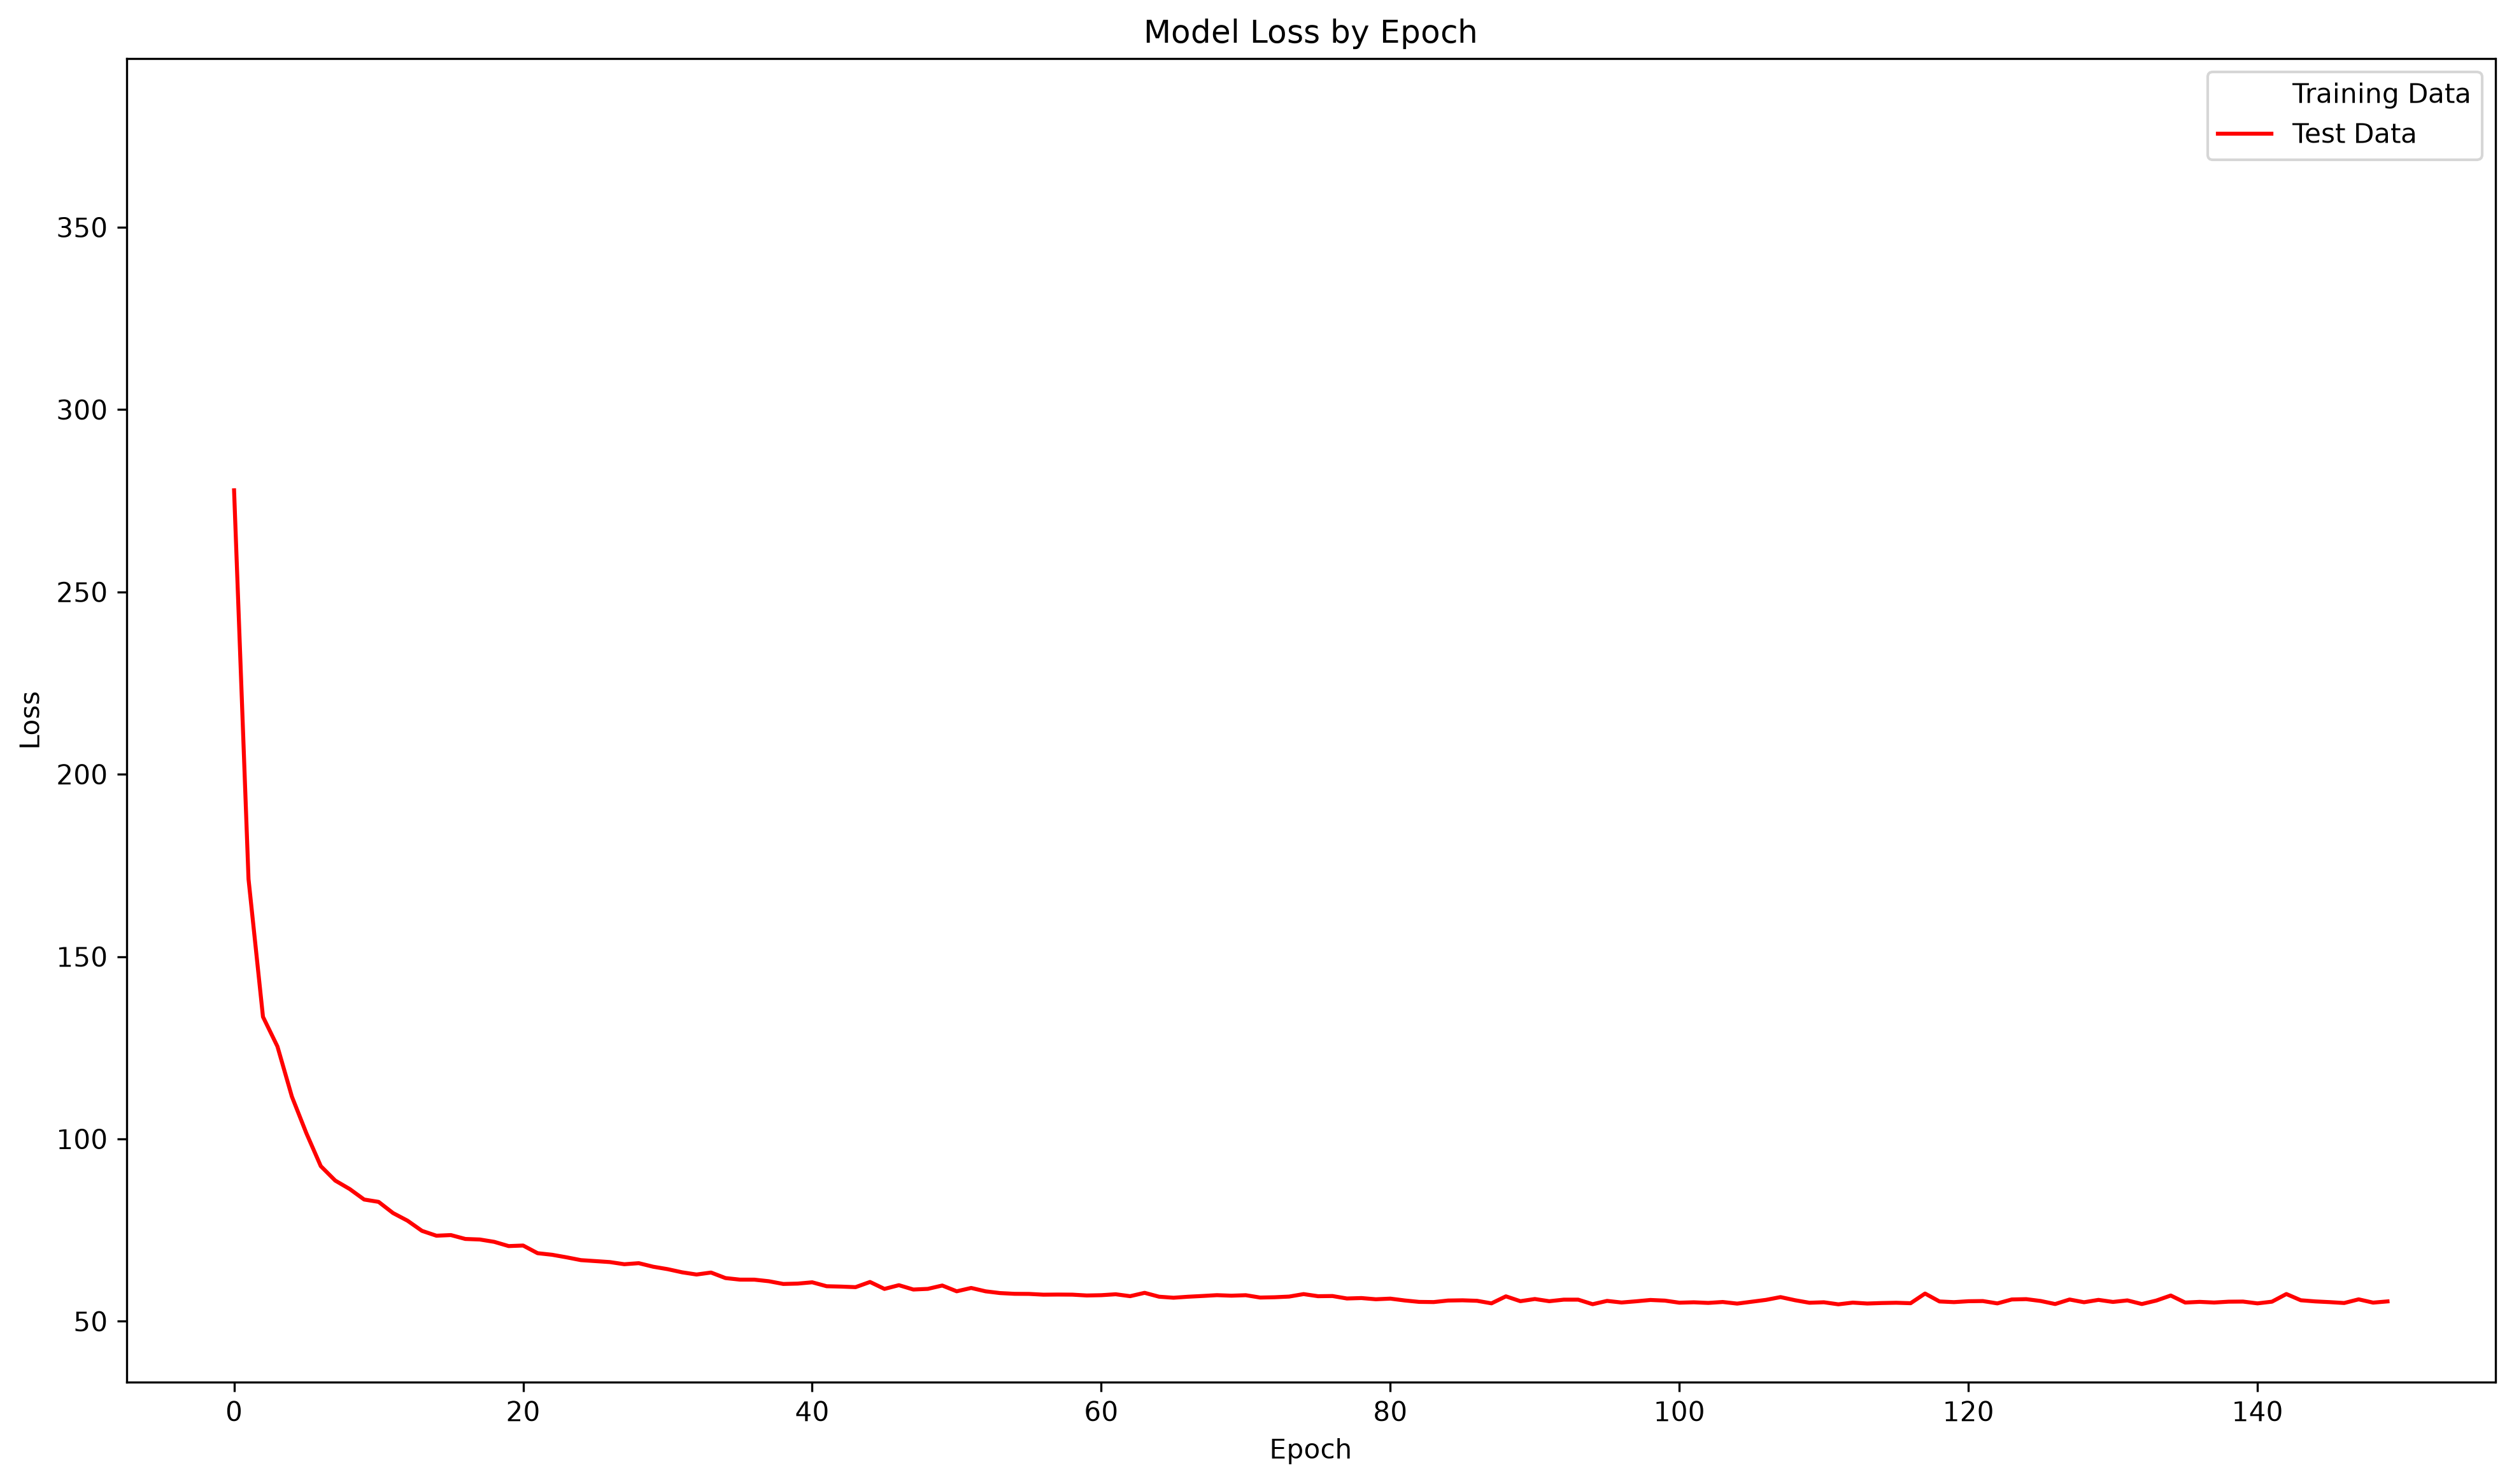

In [6]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
utils.plot_losses(training_loss, validation_loss)

## Cross validation

In [7]:
cross_validator = CrossValidator(vae=vae,filepath=filepath,cluster_number=cluster_number,n_runs=3)
histories = cross_validator.run(X=z500.values,y=label_indices,epochs=epochs, batch_size=batch_size)

Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 402.6948 - val_loss: 335.1767
Epoch 2/150
 1/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 326.8083

/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 56 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 239.8135 - val_loss: 198.8221
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 174.2599 - val_loss: 156.7631
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 146.6183 - val_loss: 133.5702
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 129.3450 - val_loss: 125.5399
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 119.1064 - val_loss: 114.8002
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 112.3475 - val_loss: 111.9118
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 108.5432 - val_loss: 108.6875
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 104.7103 - val_loss: 102.8932
Epoch 10/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 99.5845 - val_loss: 100.4485
Epoch 11/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 96.5435 - val_loss: 96.6337
Epoch 12/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 91.3632 - val_loss: 89.6114
Epoch 13/150
35/35 ━━━━━━━━━━━━━━━━

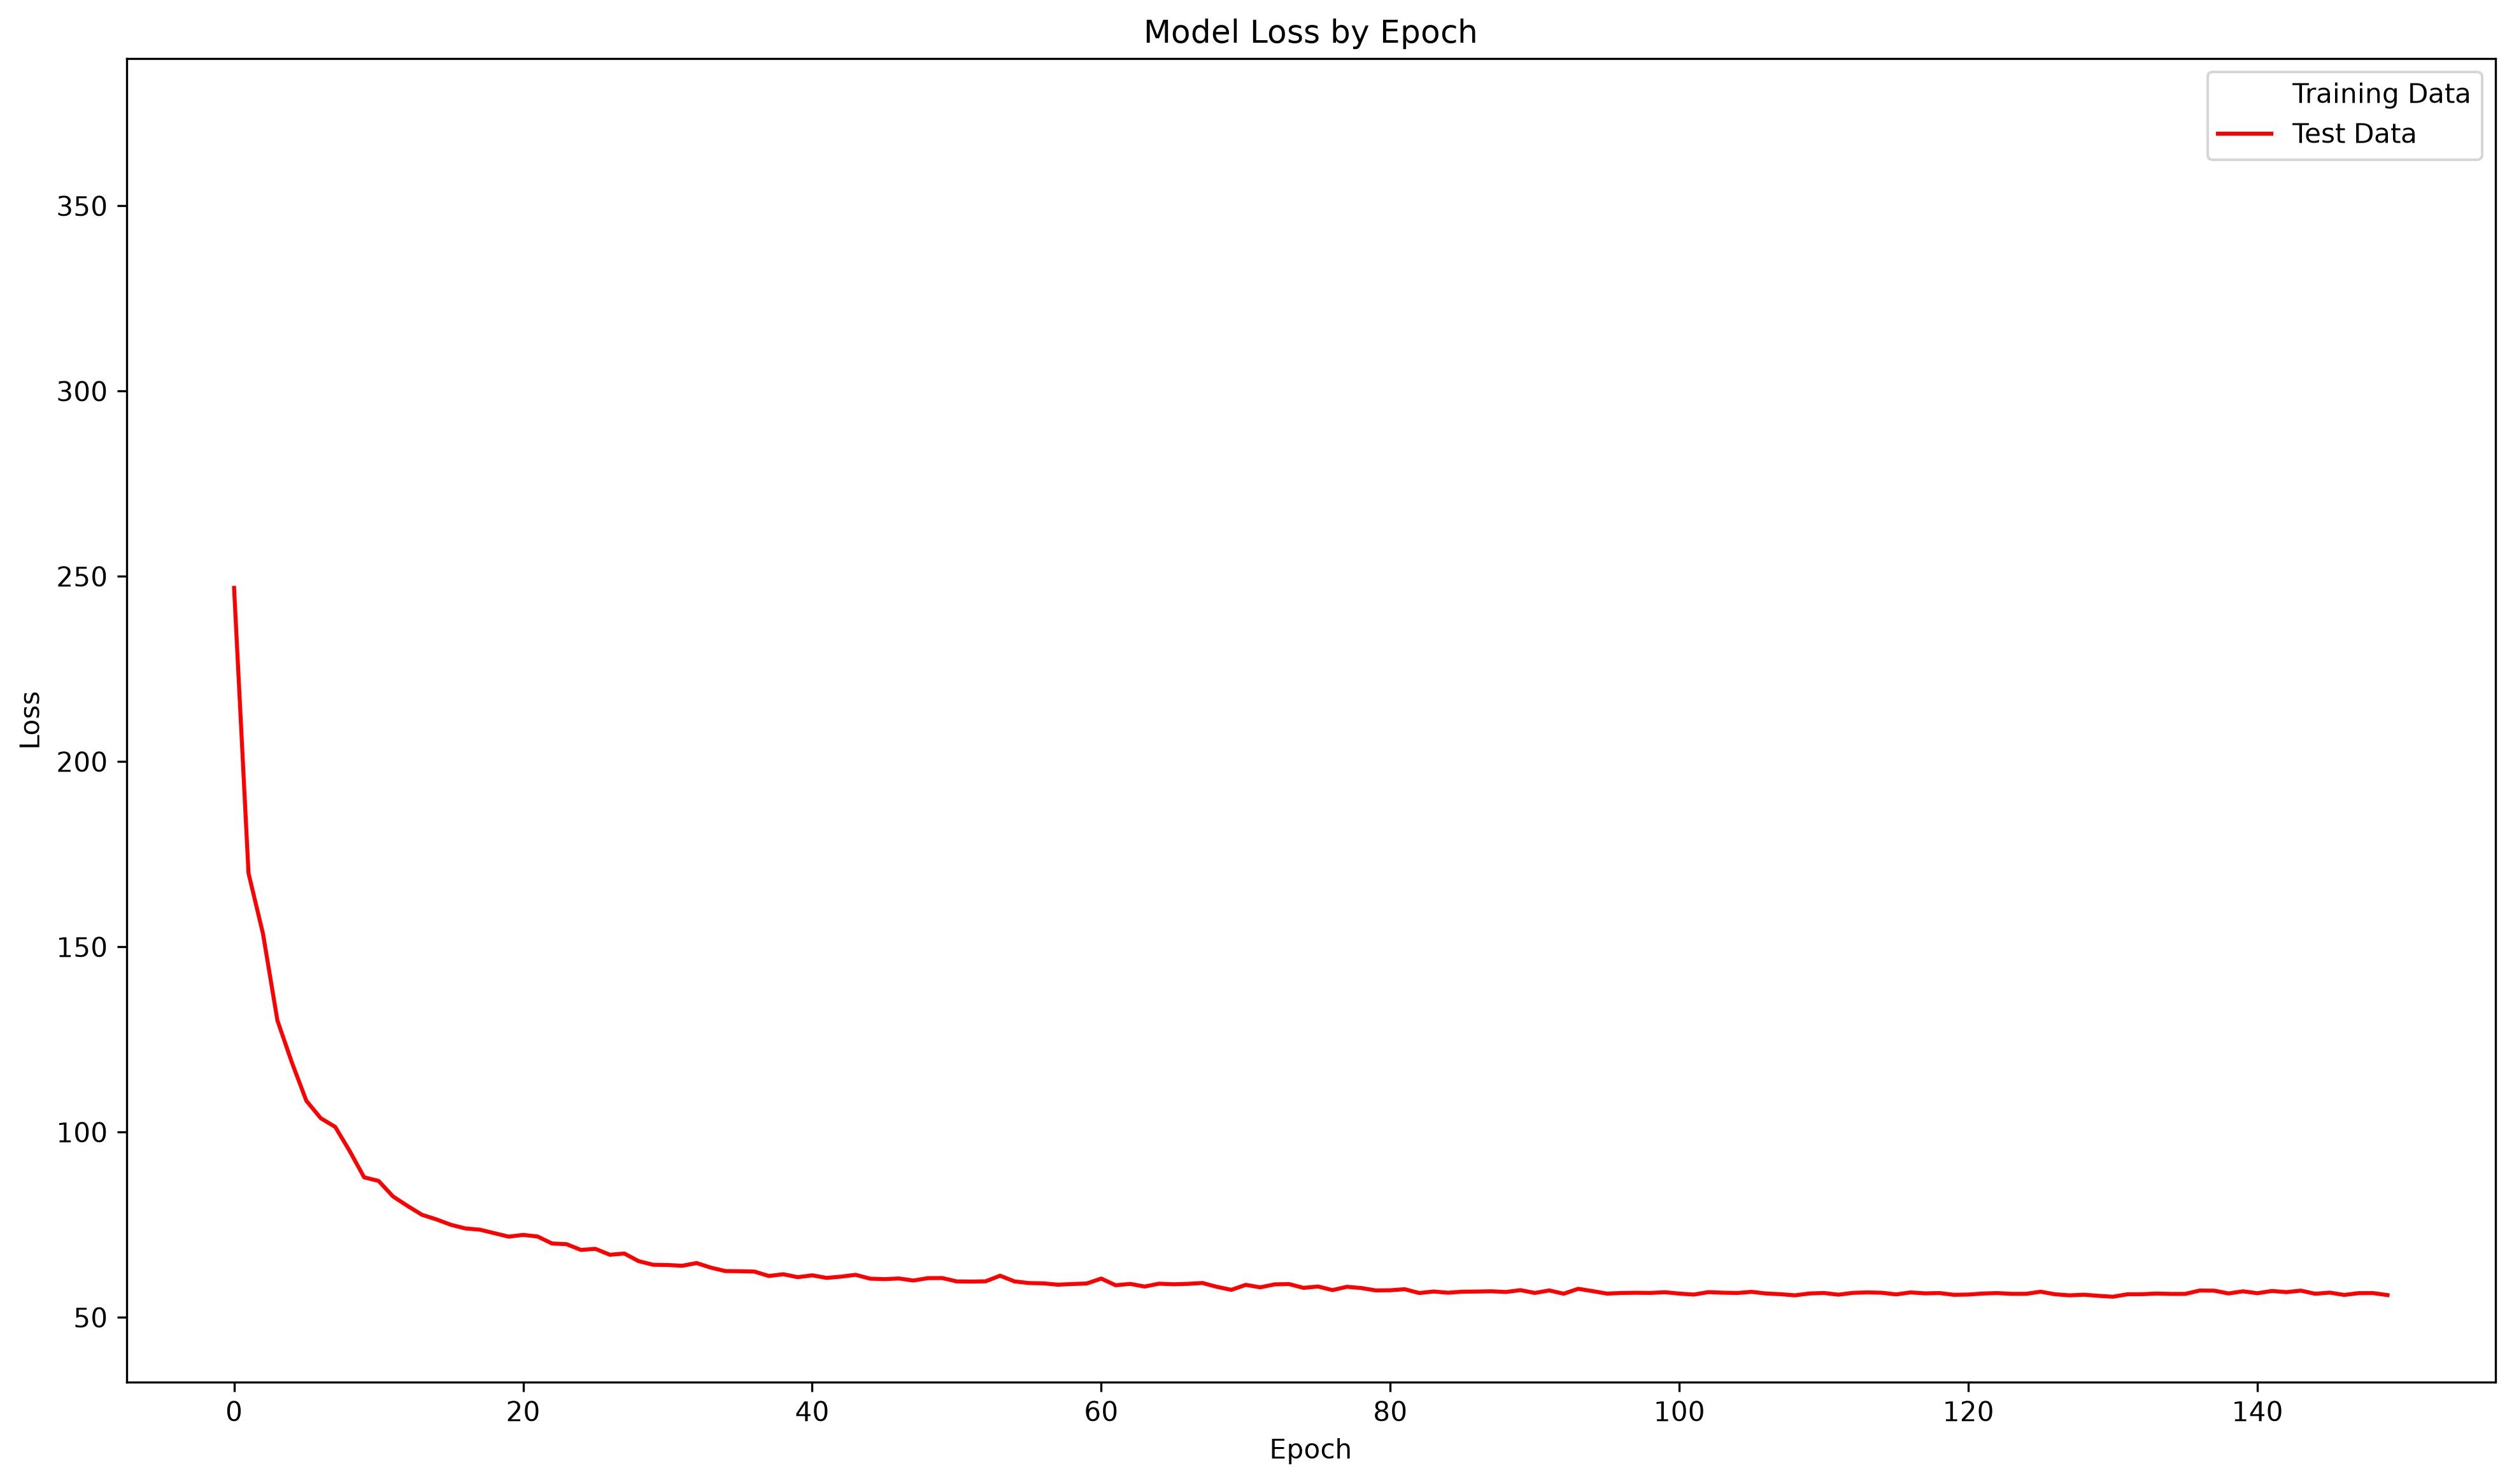

In [8]:
number = 1

training_loss = histories[number].history['loss']
validation_loss = histories[number].history['val_loss']
utils.plot_losses(training_loss, validation_loss)

## Evaluation

In [5]:
import xarray as xr

In [6]:
precip = utils.preprocess_dataset(filename ='data/CHIRPS_morocco_1980_2022.nc',
                              variable_name = 'precipitation_amount',
                              multiplication_factor = 1,
                              geographical_filter = 'global',
                              months_filter = extended_winter_months,
                              anomalies = False,
                              normalization = False,
                              rolling_window = 3)
precip = precip.where(precip['time.year'] <= 2022, drop=True)
precip_95th_percentile = precip.quantile(0.95, dim='time')
precip_above_95th = 1. * (precip > precip_95th_percentile)

/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [18]:
def make_plots(run_id):
    vae.initialize_weights_from(filepath + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
    eval_plots.plot_reordered_centers_and_odds_ratio(vae, z500, precip_above_95th)

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step


/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


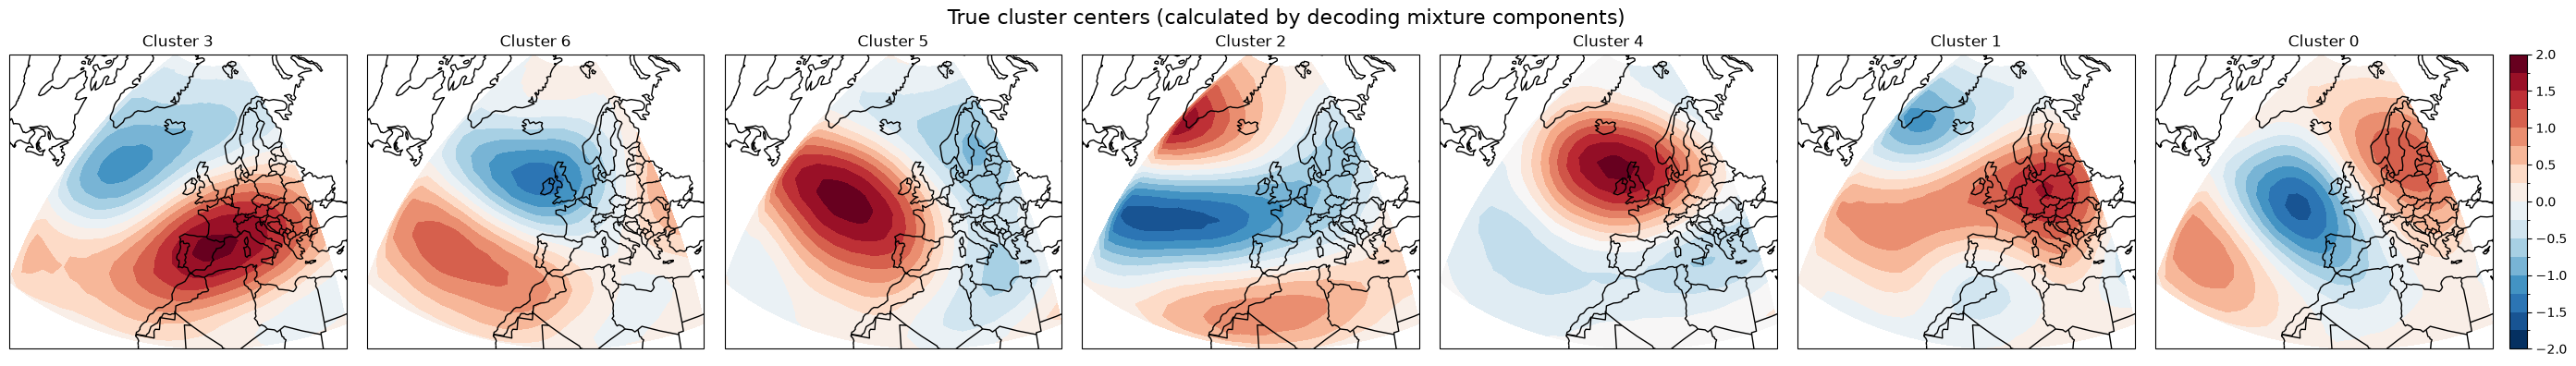

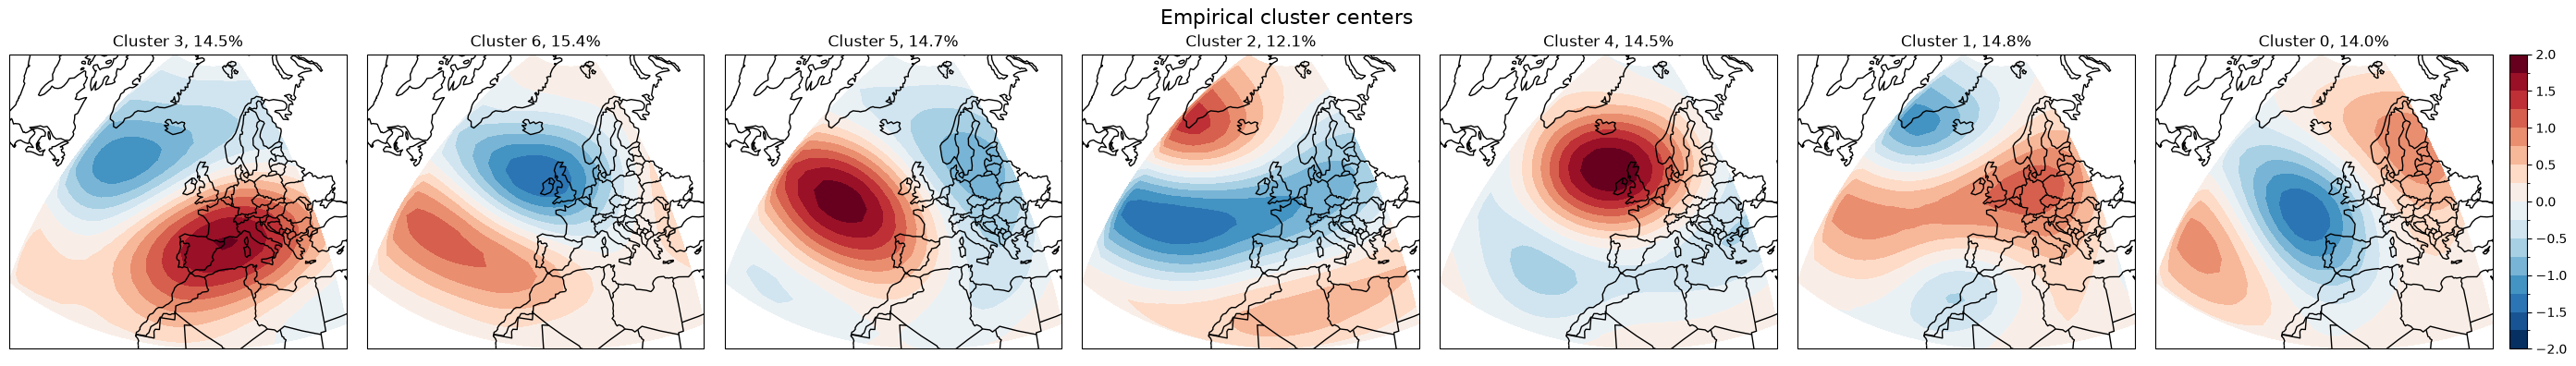

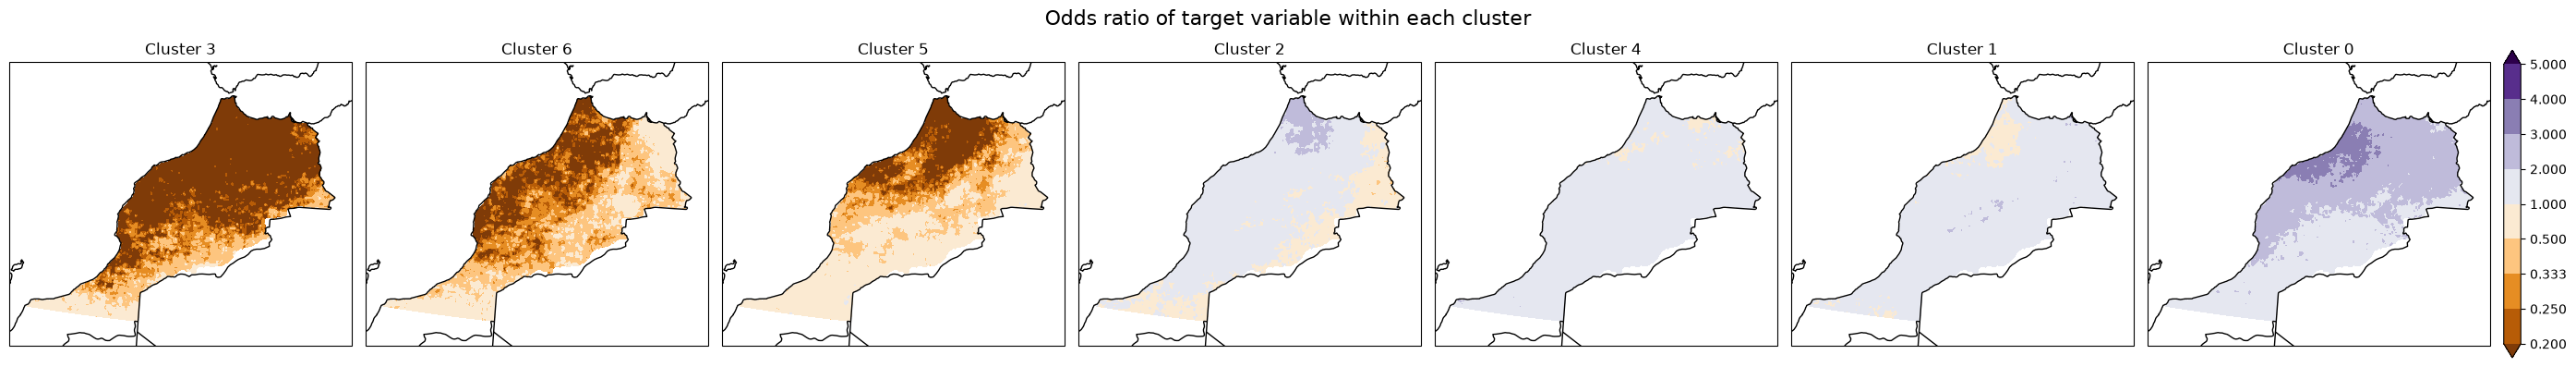

In [19]:
make_plots(0)

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 420us/step


/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


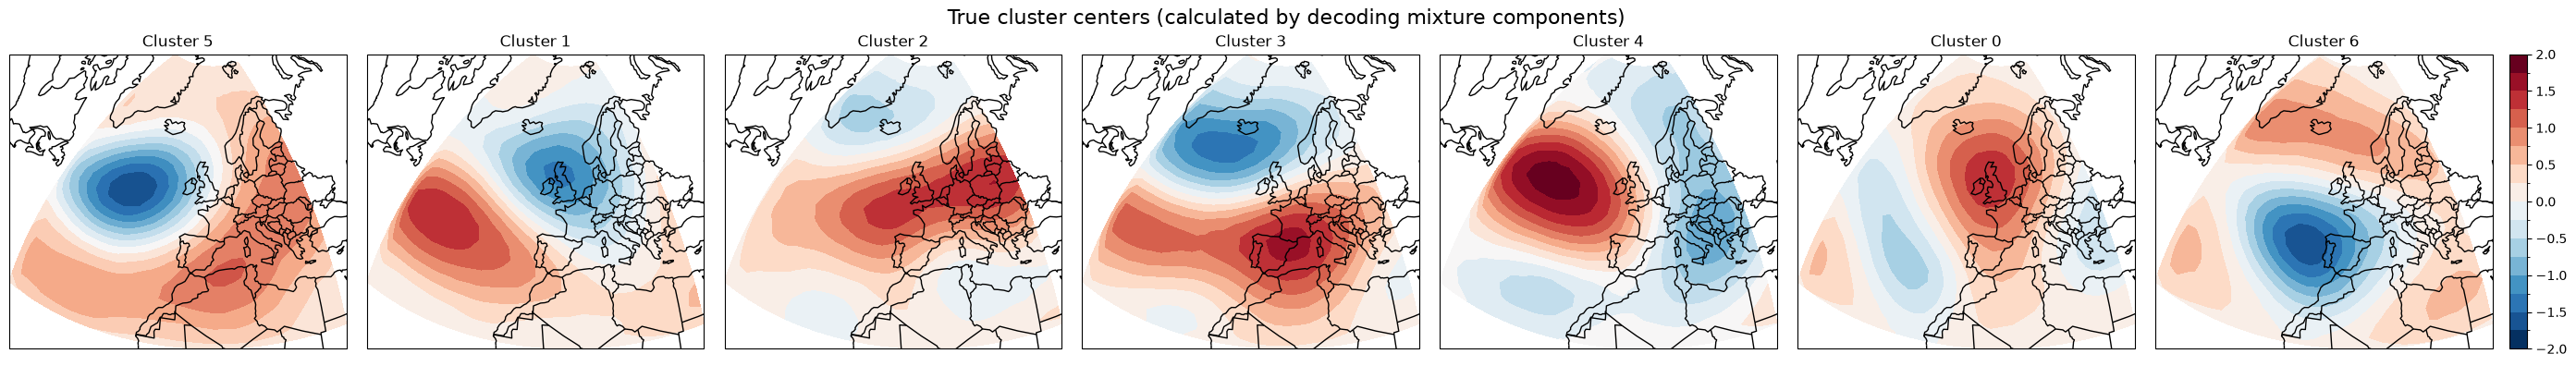

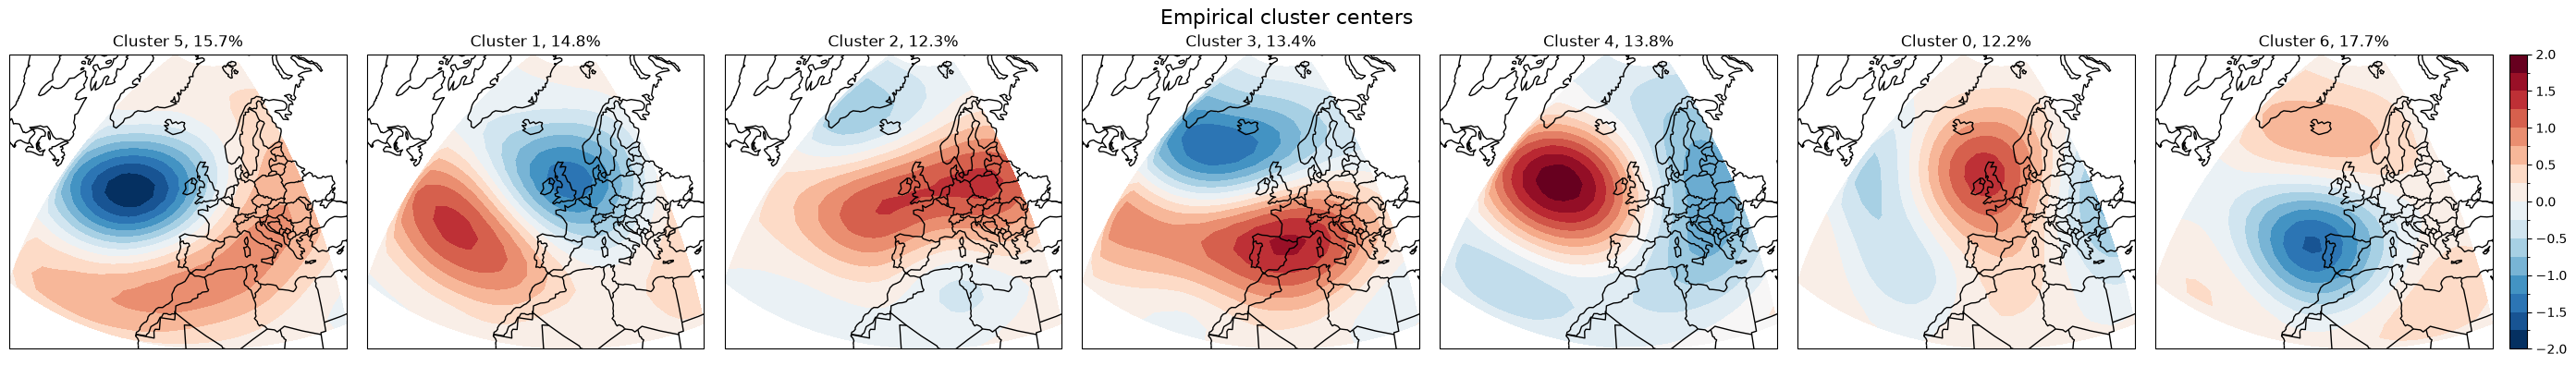

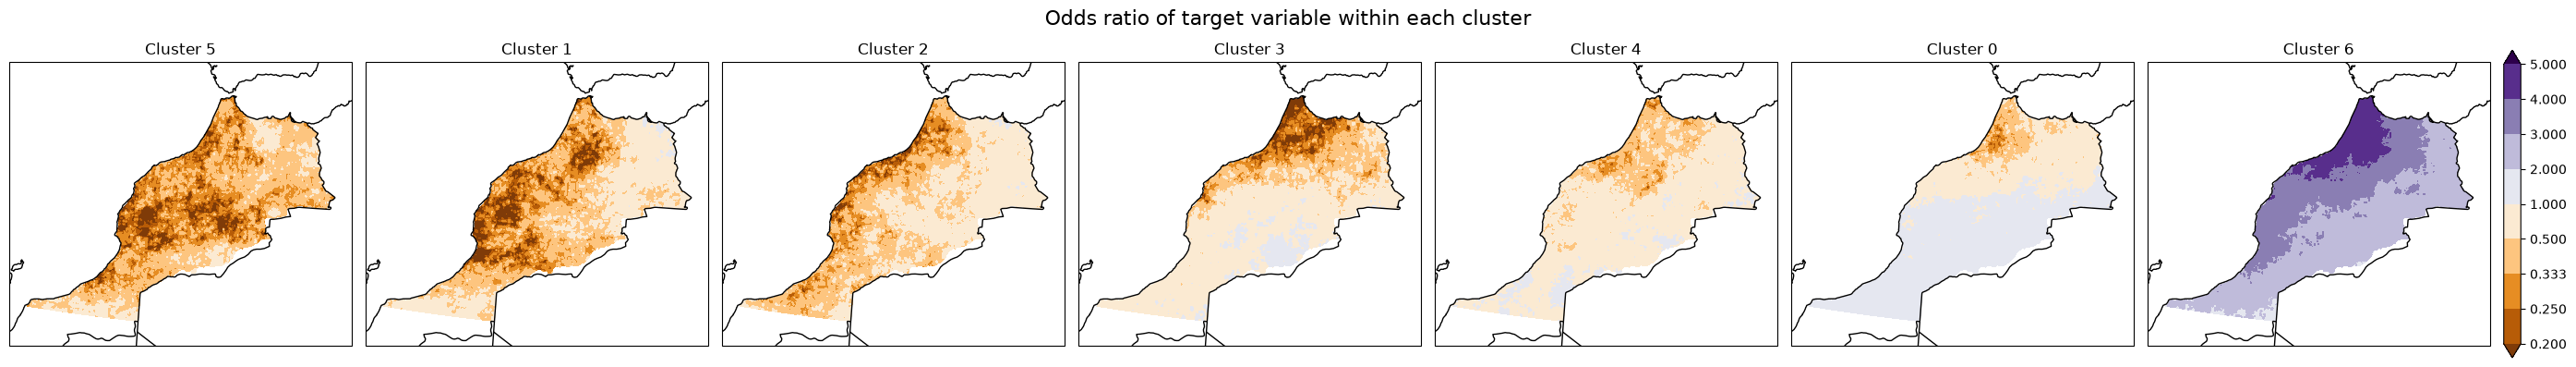

In [33]:
make_plots(2)

In [27]:
def compute_and_print_scores(run_id):
    vae.initialize_weights_from(filepath + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
    bss_precip_clusters = compute_BSS_clusters_target(vae, z500.values, label_indices)
    bss_precip_quantile_exceedance = compute_BSS_quantile_exceedance(vae, z500.values, precip.values, q = 0.95)
    bss_precip_terciles = compute_BSS_quantile_prediction(vae, z500.values, precip.values, N = 3)

    print("Run ID:", run_id)
    print(f"Brier skill score for precipitation clusters: {bss_precip_clusters:.3f}")
    print(f"Brier skill score for exceedance of 95th percentile per grid point: {bss_precip_quantile_exceedance:.3f}")
    print(f"Brier skill score for terciles per grid point: {bss_precip_terciles:.3f}")

In [28]:
compute_and_print_scores(0)

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step


/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step


/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step
Run ID: 0
Brier skill score for precipitation clusters: 0.098
Brier skill score for exceedance of 95th percentile per grid point: 0.028
Brier skill score for terciles per grid point: 0.038


In [29]:
compute_and_print_scores(2)

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step


/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 56 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step


/Users/qnicolas/miniforge3/envs/cmmvae/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 421us/step
Run ID: 2
Brier skill score for precipitation clusters: 0.161
Brier skill score for exceedance of 95th percentile per grid point: 0.054
Brier skill score for terciles per grid point: 0.054


# 